# Aula 36 - Modelo de regressão logística multiclasse

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
rng = np.random.default_rng(7)

In [3]:
def designmatrix(X, grau):
  X = np.asarray(X, float)
  x1 = X[:,0:1]
  x2 = X[:, 1:1+1]
  cols = [np.ones((X.shape[0],1))]
  for i in range(grau+1):
    for j in range(grau+1-i):
      if i==0 and j==0:
        continue
      cols.append(x1**i * x2**j) # gera todos os graus possíveis até o grau máximo, incluindo
                                  # combinações entre x1 e x2, obedecendo i+j<=grau
  return np.hstack(cols)

In [4]:
def traintestsplitMC(X, y, test_size=0.25, seed=7):

    n = len(y)
    rng = np.random.default_rng(seed)
    # Pega os indices de cada classe
    indicesporclasse = [np.where(y == c)[0] for c in np.unique(y)]


    #idx0, idx1
    tr_idx, te_idx = [], []

    # Embaralha os indices de cada classe
    for indices in indicesporclasse:
        rng.shuffle(indices)
        n_te = int(round(test_size * len(indices)))
        te_idx.append(indices[:n_te])
        tr_idx.append(indices[n_te:])

    # concatena os conjuntos de indices de cada classe, assim como era feito no caso binario
    # A diferença é que aqui vc tem uma lista com varios arrays, enquanto na versão
    # anterior vc tinha apenas dois arrays
    tr_idx = np.concatenate(tr_idx)
    te_idx = np.concatenate(te_idx)
    rng.shuffle(tr_idx)
    rng.shuffle(te_idx)

    return X[tr_idx], X[te_idx], y[tr_idx], y[te_idx]


def softmax(Z):
    # a função softmax substitui a sigmoide

    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

def loglossgradMC(W, X, y, lam):
    """
w= [w0, w01, w02;
    w1, w11, w12;
    w2, w21, w22]

    W: matriz de coeficientes (num_features, num_classes)
    X: Design matrix (num_amostras, num_features)
    y: classes reais como inteiros (0, 1, ..., K-1) sendo K o número de classes O tamanhos de y é igual a num_amostras

    lembrando que aqui o num_features não é só dos features escolhidos do dataframe,
    mas também do grau escolhido e também com uma coluna a mais para intercepto.
    Por enquanto usamos apenas 2 features do data frame, então o num_features é
    (grau+1)*(grau+2)/2

    lam: L2 força de regularização
    """
    N, D = X.shape
    K = W.shape[1]

    # One-Hot Encode
    # cria um array que codifica as classes no seguinte formato:
    # Y_one_hot[0,:] = [0, 0, 1] isso indica que o elemento zero é da classe K-1 (K=3)
    # y=   0  1   2
    # y = [1, 0 , 0]
    Y_one_hot = np.zeros((N, K))  # inicia como um array de zeros
    Y_one_hot[np.arange(N), y] = 1  # o array terá 1 apenas na posição correspondente a sua classe

    # Calcula z e as probabilidades para cada classe
    Z = X @ W  # X(N,D)  W(D,K)  ->  Z(N,K)
    P = softmax(Z)  # Probabilidades calculada com a softmax. P tem mesma dimensão de Z e Y_one_hot

    #o calculo da perda é de certa forma mais simples por conta de como as classes são separadas
    loss = -np.sum(Y_one_hot * np.log(P)) / N  #Soma todos as log(Probs) de todas a previsões da classe correta.

    # Adiciona a penalização L2 (ridge) (Excluindo o termo constante (intercepto, vies))
    l2_penalty = (lam / 2) * np.sum(W[1:, :]**2)
    loss += l2_penalty

    #Calcula o gradiente da mesma maneira. Unica diferença é o formato da matriz
    # de gradiente
    grad = (X.T @ (P - Y_one_hot)) / N

    # Adiciona tambem o gradiente da penalização: lam/2*W^2 -> 2*lam/2*W^(2-1)
    grad[1:, :] += lam * W[1:, :]

    return loss, grad

def ajustelogisticoMC(X, y, K, lam=1e-2, ta=0.1, iters=2000, tol=1e-7):
    """
    X: Design matrix (num_amostras, num_features)
    y: classes reais como inteiros (0, 1, ..., K-1) sendo K o número de classes

    lembrando novamente que o num_features não é só dos features escolhidos do dataframe,
    mas também do grau escolhido e também com uma coluna a mais para intercepto.
    Por enquanto usamos apenas 2 features do data frame, então o num_features é
    (grau+1)*(grau+2)/2

    """
    N, D = X.shape

    # inicializando W com num_features linhas e num_classes colunas
    W = np.zeros((D, K))
    prev_loss = np.inf

    # aqui é tudo semelhante ao caso binário
    for t in range(iters):

        loss, grad = loglossgradMC(W, X, y, lam)

        W -= ta * grad

        if abs(prev_loss - loss) < tol:
            break
        prev_loss = loss

    return W


# funções de validação cruzada ajustadas para o caso multiclasse
def kfolds_idxMC(y, k=5, seed=42, shuffle=True):
  y = np.asarray(y, int)

  indicesporclasse = [np.where(y == c)[0] for c in np.unique(y)]

  rng = np.random.default_rng(seed)

  foldsporclasse = []
  for indices in indicesporclasse:
    rng.shuffle(indices)
    foldsporclasse.append(np.array_split(indices, k))


      # Combine the splits to create the final folds
  folds = []
  for i in range(k):
    fold_i = np.concatenate([class_splits[i] for class_splits in foldsporclasse])
    folds.append(fold_i)

  return folds

# essa função é praticamente igual a cv_grid, porém chamando as versões MC
def cv_gridMC(X , y , graus, lambdas, k= 5, seed =42, ta=0.1, iters=2000):

    folds = kfolds_idxMC(y_tr, k=k, seed=seed)
    results = []
    num_classes = len(np.unique(y_tr))

    for d in graus:
        for lam in lambdas:
            losses = []
            for f in range(k):

                va_idx = folds[f]
                tr_idx = np.concatenate([folds[i] for i in range(k) if i != f])
                Xtr_fold = designmatrix(X[tr_idx], d)
                Xva_fold = designmatrix(X[va_idx], d)
                Xtr_s, mu, sd = standardize_train(Xtr_fold)
                Xva_s = standardize_apply(Xva_fold, mu, sd)

                W = ajustelogisticoMC(Xtr_s, y_tr[tr_idx], K=num_classes, lam=lam, ta=ta, iters=iters)


                val_loss, _ = loglossgradMC(W, Xva_s, y_tr[va_idx], lam)
                losses.append(val_loss)

            results.append((float(np.mean(losses)), d, float(lam)))

    best = min(results, key=lambda t: t[0])
    return results, best

def predict_proba_MC(Xs, W):

    return softmax(Xs @ W)

def predict_MC(Xs, W):

    probas = predict_proba_MC(Xs, W)
    return np.argmax(probas, axis=1)


def plotarlimitesMC(X_raw, y, mu, sd, W, degree, title = "diga algo"):

    x1min, x1max = X_raw[:,0].min() - 5, X_raw[:,0].max() + 5
    x2min, x2max = X_raw[:,1].min() - 5, X_raw[:,1].max() + 5

    gx1, gx2 = np.meshgrid(np.linspace(x1min, x1max, 200),
                           np.linspace(x2min, x2max, 200))

    Xg_raw = np.c_[gx1.ravel(), gx2.ravel()]
    Xg_poly = designmatrix(Xg_raw, degree)
    Xg_s = standardize_apply(Xg_poly, mu, sd)

    # faz a previsão para cada ponto do grid. Isso permite dar o efeito de preenchimento de cada região
    Z = predict_MC(Xg_s, W).reshape(gx1.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(gx1, gx2, Z, alpha=0.3, cmap='viridis')
    scatter = plt.scatter(X_raw[:,0], X_raw[:,1], c=y, cmap="viridis", s=50, edgecolor="k", linewidth=0.5)

    handles, _ = scatter.legend_elements()
    legend_labels = list(species_map.keys())
    plt.legend(handles, legend_labels, title="Species")

    plt.title(title)
    plt.xlabel(feature_cols[0])
    plt.ylabel(feature_cols[1])
    plt.show()


def plotlimitespca(X_pca, y, W,d, title="PCA Space"):

    x1_min, x1_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    x2_min, x2_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

    gx1, gx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                           np.linspace(x2_min, x2_max, 200))

    Xg_pca = np.c_[gx1.ravel(), gx2.ravel()]
    Xg_pca_intercept = designmatrix(Xg_pca,d)

    Z = predict_MC(Xg_pca_intercept, W).reshape(gx1.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(gx1, gx2, Z, alpha=0.3, cmap='viridis')
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis", s=50, edgecolor="k", linewidth=0.5)

    handles, _ = scatter.legend_elements()
    legend_labels = list(species_map.keys())
    plt.legend(handles, legend_labels, title="Espécies")

    plt.title(title)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.show()

def designmatrix(X, grau):
    X = np.asarray(X, float)
    if len(X.shape) == 1:
        X = X.reshape(-1, 1)
    if X.shape[1] == 1:
        x1 = X
        x2 = X.copy()
    else:
        x1 = X[:,0:1]
        x2 = X[:, 1:1+1]
    cols = [np.ones((X.shape[0],1))]
    for i in range(1, grau + 1):
        for j in range(i + 1):
            cols.append((x1**(i-j)) * (x2**j))
    return np.hstack(cols)

def traintestsplitMC(X, y, test_size=0.25, seed=7):
    n = len(y)
    rng = np.random.default_rng(seed)
    indicesporclasse = [np.where(y == c)[0] for c in np.unique(y)]
    tr_idx, te_idx = [], []
    for indices in indicesporclasse:
        rng.shuffle(indices)
        n_te = int(round(test_size * len(indices)))
        te_idx.append(indices[:n_te])
        tr_idx.append(indices[n_te:])
    X_tr = X[np.concatenate(tr_idx)]
    X_te = X[np.concatenate(te_idx)]
    y_tr = y[np.concatenate(tr_idx)]
    y_te = y[np.concatenate(te_idx)]
    return X_tr, X_te, y_tr, y_te

def standardize_train(X):
    mu = X.mean(axis=0)
    sd = X.std(axis=0)
    if sd.ndim > 0 and len(sd) > 1:
        sd[0] = 1
    X_s = (X - mu) / sd
    return X_s, mu, sd

def standardize_apply(X, mu, sd):
    return (X - mu) / sd

def softmax(Z):
    Z_exp = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return Z_exp / np.sum(Z_exp, axis=1, keepdims=True)

def loglossgradMC(W, X, y, lam):
    N, D = X.shape
    K = W.shape[1]
    y = y.astype(int)
    Y_one_hot = np.zeros((N, K))
    Y_one_hot[np.arange(N), y] = 1
    Z = X @ W
    P = softmax(Z)
    log_likelihood = -np.sum(Y_one_hot * np.log(P + 1e-12))
    loss = (1/N) * log_likelihood + (lam/2) * np.sum(W[1:,:]**2)
    grad = (1/N) * X.T @ (P - Y_one_hot)
    grad[1:,:] += lam * W[1:,:]
    return loss, grad

def ajustelogisticoMC(X, y, K, lam, ta, iters, tol=1e-6):
    N, D = X.shape
    W = np.zeros((D, K))
    prev_loss = np.inf
    for t in range(iters):
        loss, grad = loglossgradMC(W, X, y, lam)
        W -= ta * grad
        if abs(prev_loss - loss) < tol:
            break
        prev_loss = loss
    return W

def kfolds_idxMC(n, k, seed):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    folds = np.array_split(idx, k)
    return folds

def cv_gridMC(X_raw, y, degrees, lambdas, k, seed):
    ta, iters = 0.1, 5000
    results = []
    num_classes = len(np.unique(y))
    best_loss = np.inf
    best_params = None
    for d in degrees:
        X = designmatrix(X_raw, d)
        for lam in lambdas:
            folds = kfolds_idxMC(len(y), k, seed)
            losses = []
            for i in range(k):
                va_idx = folds[i]
                tr_idx = np.concatenate([folds[j] for j in range(k) if j != i])
                Xtr_fold, Xva_fold = X[tr_idx], X[va_idx]
                ytr_fold, yva_fold = y[tr_idx], y[va_idx]
                Xtr_s, mu, sd = standardize_train(Xtr_fold)
                Xva_s = standardize_apply(Xva_fold, mu, sd)
                W = ajustelogisticoMC(Xtr_s, ytr_fold, K=num_classes, lam=lam, ta=ta, iters=iters)
                val_loss, _ = loglossgradMC(W, Xva_s, yva_fold, lam)
                losses.append(val_loss)
            mean_loss = np.mean(losses)
            results.append([mean_loss, d, lam])
            if mean_loss < best_loss:
                best_loss = mean_loss
                best_params = [mean_loss, d, lam]
    results = pd.DataFrame(results, columns=['loss', 'd', 'lambda'])
    return results, best_params

def predict_MC(X, W):
    return np.argmax(softmax(X @ W), axis=1)

def plotarlimitesMC(X_raw, y, W, degree, mu, sd):
    x1min, x1max = X_raw[:,0].min() - 0.5, X_raw[:,0].max() + 0.5
    x2min, x2max = X_raw[:,1].min() - 0.5, X_raw[:,1].max() + 0.5
    gx1, gx2 = np.meshgrid(np.linspace(x1min, x1max, 200),
                           np.linspace(x2min, x2max, 200))
    Xg_raw = np.c_[gx1.ravel(), gx2.ravel()]
    Xg_poly = designmatrix(Xg_raw, degree)
    Xg_s = standardize_apply(Xg_poly, mu, sd)
    Z = predict_MC(Xg_s, W).reshape(gx1.shape)
    plt.figure(figsize=(10, 8))
    plt.contourf(gx1, gx2, Z, alpha=0.3, cmap='viridis')
    scatter = plt.scatter(X_raw[:,0], X_raw[:,1], c=y, cmap="viridis", s=50, edgecolor="k", linewidth=0.5)
    plt.xlabel("PC 1") # Rótulo ajustado
    plt.ylabel("PC 2") # Rótulo ajustado
    plt.title("Previsões do Modelo no Espaço de PC1 e PC2") # Título ajustado
    plt.show()

In [5]:
def standardize_train(X): # padronização das variaveis (exceto a constante)
  X = np.asarray(X, float)
  Xs = X.copy()
  mu = X[:,1:].mean(axis=0, keepdims=True)
  sd = X[:,1:].std(axis=0, ddof = 0, keepdims=True)
  sd = np.where(sd==0, 1, sd)
  Xs[:,1:] = (X[:,1:] - mu)/sd
  return Xs, mu, sd

def standardize_apply(X, mu, sd): # a padronização calculada no treino deve ser aplicada ao conjunto de teste
  Xs = X.copy()
  Xs[:,1:] = (X[:,1:]-mu)/sd
  return Xs

In [6]:
def sigmoid(z):
  return 1.0/(1.0 +np.exp(-z))

In [7]:
penguin_url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"
df = pd.read_csv(penguin_url)
df.dropna(inplace=True)


species_map = {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}
y = df['species'].map(species_map).values


feature_cols = ['flipper_length_mm', 'bill_length_mm']
X_o = df[feature_cols].values
print(df.columns)
X_tr_o, X_te_o, y_tr, y_te = traintestsplitMC(X_o, y, test_size=0.3, seed=7)


URLError: <urlopen error [Errno 11001] getaddrinfo failed>

In [ ]:
d= 2; lam=0

Xtr = designmatrix(X_tr_o, d)
Xtr_s, mu, sd = standardize_train(Xtr)
num_classes = len(np.unique(y_tr))

W_final = ajustelogisticoMC(Xtr_s, y_tr, K=num_classes, lam=lam, ta=0.1, iters=2000)

print(Xtr.shape)

(233, 6)


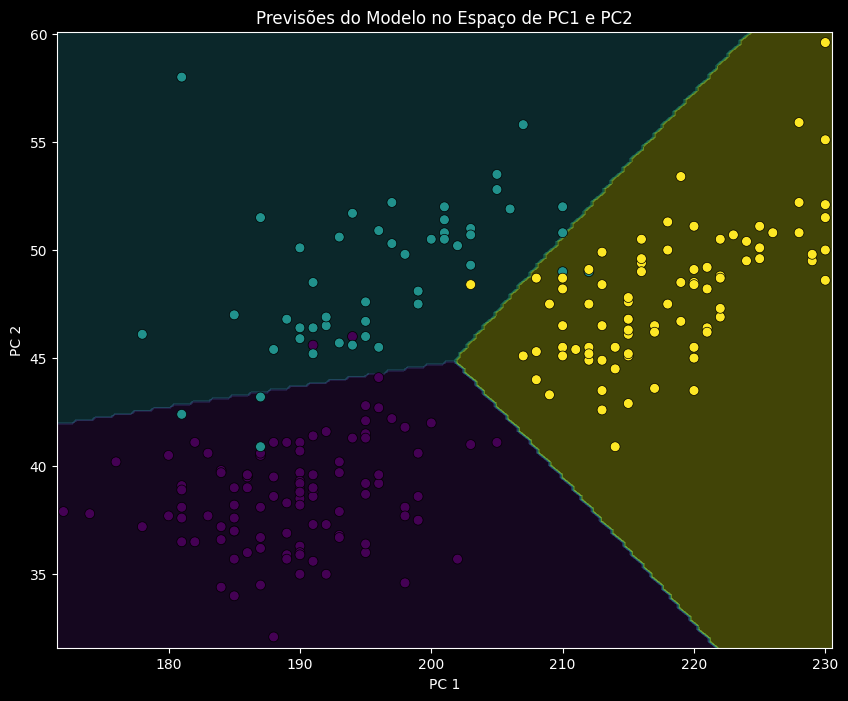

In [ ]:
plotarlimitesMC(X_tr_o,y_tr,W=W_final,degree=d, sd=sd,mu=mu)

In [ ]:
penguin_url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"
df = pd.read_csv(penguin_url)
df.dropna(inplace=True)


species_map = {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}
y = df['species'].map(species_map).values


feature_cols = ['flipper_length_mm', 'bill_length_mm','bill_depth_mm','body_mass_g']
X_o = df[feature_cols].values
print(df.columns)
X_tr_o, X_te_o, y_tr, y_te = traintestsplitMC(X_o, y, test_size=0.3, seed=7)


Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='object')


In [ ]:

def pca_svd(X_std, n_components=2):

    U, S, Vt = np.linalg.svd(X_std, full_matrices=False)

    projection_matrix = Vt.T
    projection_matrix = projection_matrix[:, :n_components]

    X_pca = U[:, :n_components] * S[:n_components]

    explained_variance = S**2 / (len(X_std) - 1)
    total_variance = np.sum(explained_variance)
    explained_variance_ratio = explained_variance / total_variance

    print(f"--- PCA ---")
    print(f"Var de PC1: {explained_variance_ratio[0]:.2%}")
    print(f"Var de PC2: {explained_variance_ratio[1]:.2%}")
    print(f"Total var de top 2: {np.sum(explained_variance_ratio[:n_components]):.2%}")

    return X_pca, projection_matrix

def standardize_features(X):
    # padronização dos dados brutos para o pca (sem designmatrix)
    X = np.asarray(X, float)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, ddof=0, keepdims=True)
    sd = np.where(sd==0, 1.0, sd)
    return (X - mu) / sd, mu, sd

In [ ]:
def apply_standardization(X, mu, sd):
    return (X - mu) / sd

In [ ]:
def print_multiclass_metrics(y_true, y_pred, species_map):

    accuracy = np.mean(y_true == y_pred)
    print(f"Overall Accuracy: {accuracy:.4f}\n")

    # Create and display a confusion matrix using pandas for nice formatting
    cm = pd.crosstab(
        pd.Series(y_true, name='Actual'),
        pd.Series(y_pred, name='Predicted')
    )
    # Map indices back to species names for readability
    rev_species_map = {v: k for k, v in species_map.items()}
    cm.rename(index=rev_species_map, columns=rev_species_map, inplace=True)
    print("--- Confusion Matrix ---")
    print(cm)

In [ ]:
X_tr_s, mu, sd = standardize_features(X_tr_o)

In [ ]:
X_tr_pca, projection_matrix = pca_svd(X_tr_s, n_components=2)


--- PCA ---
Var de PC1: 69.49%
Var de PC2: 18.93%
Total var de top 2: 88.42%


In [ ]:
d=1
X_tr_pca_mat = designmatrix(X_tr_pca,d)


In [ ]:
W_pca_final = ajustelogisticoMC(
    X_tr_pca_mat, y_tr, K=num_classes,
    lam=0.01, ta=0.1, iters=5000
)

In [ ]:
X_te_s = apply_standardization(X_te_o, mu, sd)
X_te_pca = X_te_s @ projection_matrix
X_te_pca_mat = designmatrix(X_te_pca,d)

In [ ]:
y_te_pred_pca = predict_MC(X_te_pca_mat, W_pca_final)
print_multiclass_metrics(y_te, y_te_pred_pca, species_map)

Overall Accuracy: 0.8900

--- Confusion Matrix ---
Predicted  Adelie  Chinstrap  Gentoo
Actual                              
Adelie         38          6       0
Chinstrap       5         15       0
Gentoo          0          0      36


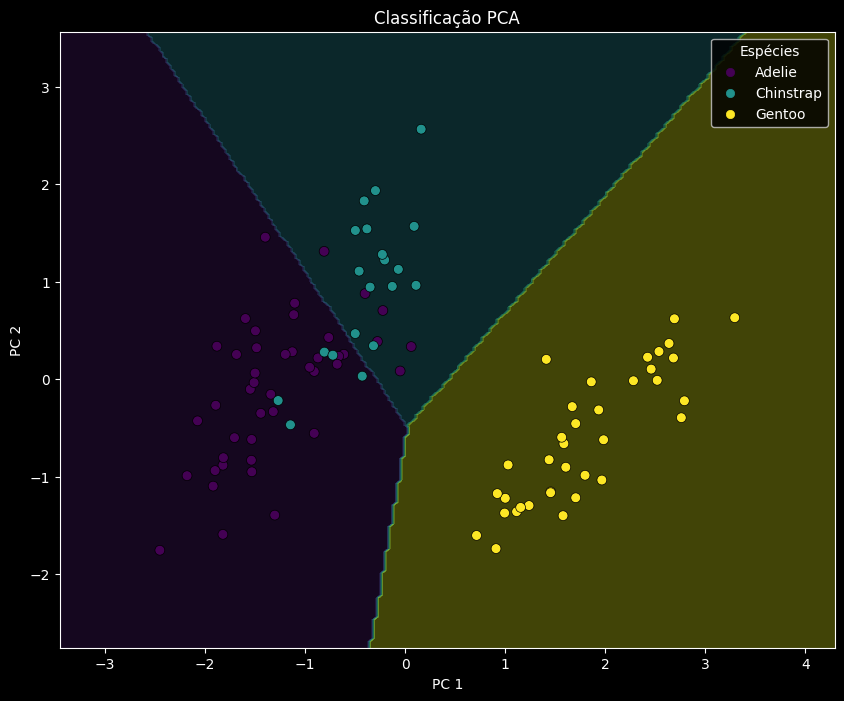

In [ ]:
plotlimitespca(X_te_pca, y_te, W_pca_final, d, title="Classificação PCA")

#(X_pca, y, W, d, title="diga aldo"):

In [ ]:
projection_matrix

array([[ 0.57370307,  0.0234526 ],
       [ 0.4593237 ,  0.58323822],
       [-0.39908748,  0.80846151],
       [ 0.54828434,  0.07532023]])

 ['flipper_length_mm',
 bill_length_mm',
 'bill_depth_mm',
 'body_mass_g']

 dada essa ordem, as features que mais contribuem em pc1 e pc2 sao bill_depth_mm seguida por bill_length_mm.

(4, 2)


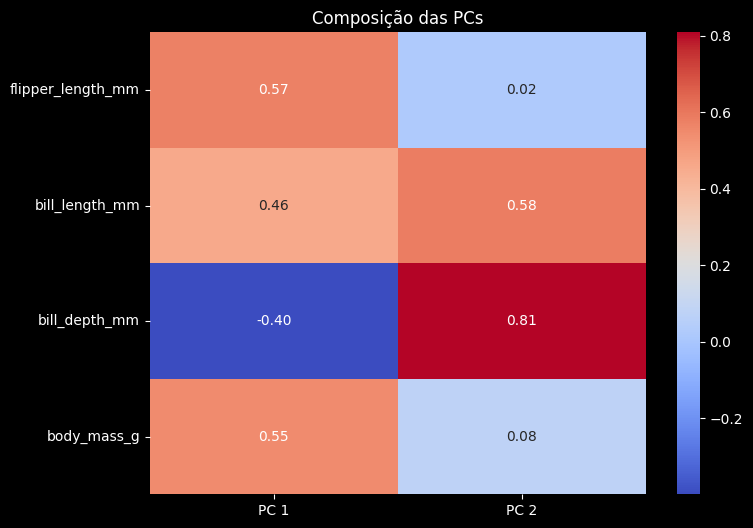

In [ ]:
import seaborn as sns

print(projection_matrix.shape)

pca_weights_df = pd.DataFrame(projection_matrix,
                              columns=['PC 1', 'PC 2'],
                              index=feature_cols)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pca_weights_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Composição das PCs')
plt.show()

# Atividade da Aula 36 - Modelo de regressão logística multiclasse

Carregar o conjunto de dados usando:

* wine_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

* wine_df = pd.read_csv(wine_url, sep=';')

Encontrar um conjunto de parâmetros capaz de prever a qualidade do vinho.



- Utilize PCA e avalie as duas principais componentes.
- Mostre a composição dessas duas componentes em função dos parâmetros originais

- Utilize um modelo de regressão logística, encontrando os melhores hiperparâmetros de grau e lambda

- Avalie a qualidade do seu modelo.
- Faça um plot no espaço de PC1 e PC2 das previsões do seu modelo.
- Explique por que seu modelo apresenta esse resultado.

### 1 - Carregando o conjunto dos dados e separando nas variáveis X e Y. 

In [ ]:
import pandas as pd
import numpy as np

# Carregar o conjunto de dados
wine_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
wine_df = pd.read_csv(wine_url, sep=';')

X = wine_df.drop('quality', axis=1).values
y_original = wine_df['quality'].values

### 2 - Analisando o arquivo para encontrar um conjunto de parâmetros capaz de prever a qualidade do vinho.

In [ ]:
unique_labels = np.unique(y_original)
y = np.zeros_like(y_original)
for i, label in enumerate(unique_labels):
    y[y_original == label] = i

print("Labels originais:", unique_labels)
print("Novos labels (0-indexed):", np.unique(y))

Labels originais: [3 4 5 6 7 8]
Novos labels (0-indexed): [0 1 2 3 4 5]


### 3 - Utilize PCA e avalie as duas principais componentes.

In [ ]:
X_s_temp, _, _ = standardize_train(np.hstack([np.ones((X.shape[0], 1)), X]))
X_s = X_s_temp[:, 1:]

cov_matrix = np.cov(X_s, rowvar=False)
autovalores, autovetores = np.linalg.eig(cov_matrix)
idx = autovalores.argsort()[::-1]
autovetores = autovetores[:, idx]
W_pca = autovetores[:, :2]
X_pca = X_s @ W_pca

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variância explicada por PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"Variância explicada por PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Variância explicada (PC1 + PC2): {np.sum(pca.explained_variance_ratio_):.4f}")

Variância explicada por PC1: 0.2817
Variância explicada por PC2: 0.1751
Variância explicada (PC1 + PC2): 0.4568


### 4 - Mostre a composição dessas duas componentes em função dos parâmetros originais

In [ ]:
pc_composition = pd.DataFrame(W_pca, columns=['PC1', 'PC2'], index=wine_df.drop('quality', axis=1).columns)
print("\nComposição das duas principais componentes:")
print(pc_composition)



Composição das duas principais componentes:
                           PC1       PC2
fixed acidity         0.489314 -0.110503
volatile acidity     -0.238584  0.274930
citric acid           0.463632 -0.151791
residual sugar        0.146107  0.272080
chlorides             0.212247  0.148052
free sulfur dioxide  -0.036158  0.513567
total sulfur dioxide  0.023575  0.569487
density               0.395353  0.233575
pH                   -0.438520  0.006711
sulphates             0.242921 -0.037554
alcohol              -0.113232 -0.386181


### 5 - Utilize um modelo de regressão logística, encontrando os melhores hiperparâmetros de grau e lambda

In [ ]:
X_tr_o, X_te_o, y_tr, y_te = traintestsplitMC(X_pca, y, test_size=0.3, seed=7)

graus = [1, 2, 3]
lambdas = [0.01, 0.1, 1, 10]
results, best = cv_gridMC(X_tr_o, y_tr, graus, lambdas, k=5, seed=42)
best_d = best[1]
best_lam = best[2]

print(f"\nMelhor grau encontrado: {best_d}")
print(f"Melhor Lambda encontrado: {best_lam}")
print("\nResultados da Validação:")
print(results.sort_values(by='loss'))


Melhor grau encontrado: 1
Melhor Lambda encontrado: 0.01

Resultados da Validação:
        loss  d  lambda
0   1.096285  1    0.01
4   1.099771  2    0.01
8   1.103172  3    0.01
1   1.128080  1    0.10
5   1.128830  2    0.10
9   1.133115  3    0.10
6   1.171390  2    1.00
2   1.171761  1    1.00
10  1.172071  3    1.00
11  1.186206  3   10.00
7   1.186314  2   10.00
3   1.186460  1   10.00


### 6 - Avalie a qualidade do seu modelo.

In [ ]:

# Treino
Xtr_poly = designmatrix(X_tr_o, best_d)
Xtr_s, mu_log, sd_log = standardize_train(Xtr_poly)
num_classes = len(unique_labels)
W_final = ajustelogisticoMC(Xtr_s, y_tr, K=num_classes, lam=best_lam, ta=0.1, iters=5000)

# Previsões no conjunto de teste
Xte_poly = designmatrix(X_te_o, best_d)
Xte_s = standardize_apply(Xte_poly, mu_log, sd_log)
y_pred = predict_MC(Xte_s, W_final)

# Calcular a acurácia
accuracy = np.mean(y_pred == y_te)
print(f"\nAcurácia do modelo no conjunto de teste: {accuracy:.4f}")


Acurácia do modelo no conjunto de teste: 0.5386


### 7 - Faça um plot no espaço de PC1 e PC2 das previsões do seu modelo.

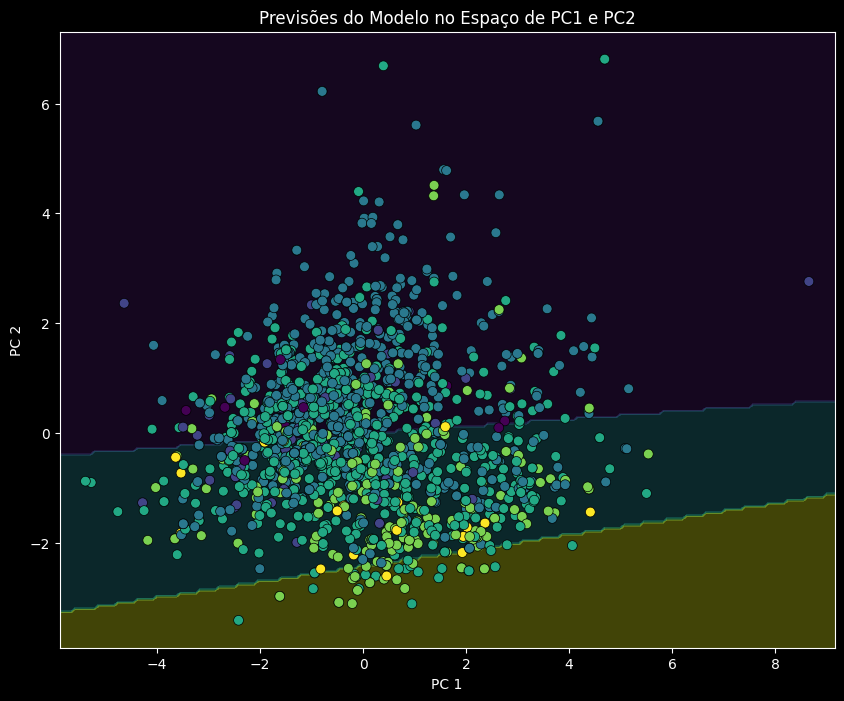

In [ ]:
plotarlimitesMC(X_pca, y, W_final, best_d, mu_log, sd_log)

### 8 - Explique por que seu modelo apresenta esse resultado.

Os componentes principais PC1 e PC2 mostram as direções de maior variação dos dados, mas isso não significa que sejam as melhores para separar as classes de qualidade do vinho. No gráfico do PCA, é possível ver que as classes se misturam bastante, o que torna a classificação mais difícil. A regressão logística tenta criar fronteiras para separar essas classes, mas, como elas não estão bem divididas no espaço 2D, o modelo não consegue atingir alta precisão. Assim, a acurácia obtida representa o melhor resultado possível nesse cenário, sendo necessário usar mais componentes ou um modelo mais complexo para melhorar o desempenho.
